- Implement various data augmentation techniques using Keras 
- Implement feature-wise and sample-wise normalization on the data set. 
- Define and apply a custom augmentation function that adds random noise to images. 
- Display the augmented images to understand the effect of different augmentation techniques. 

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Loading CIFAR-10 dataset for training imagees
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()


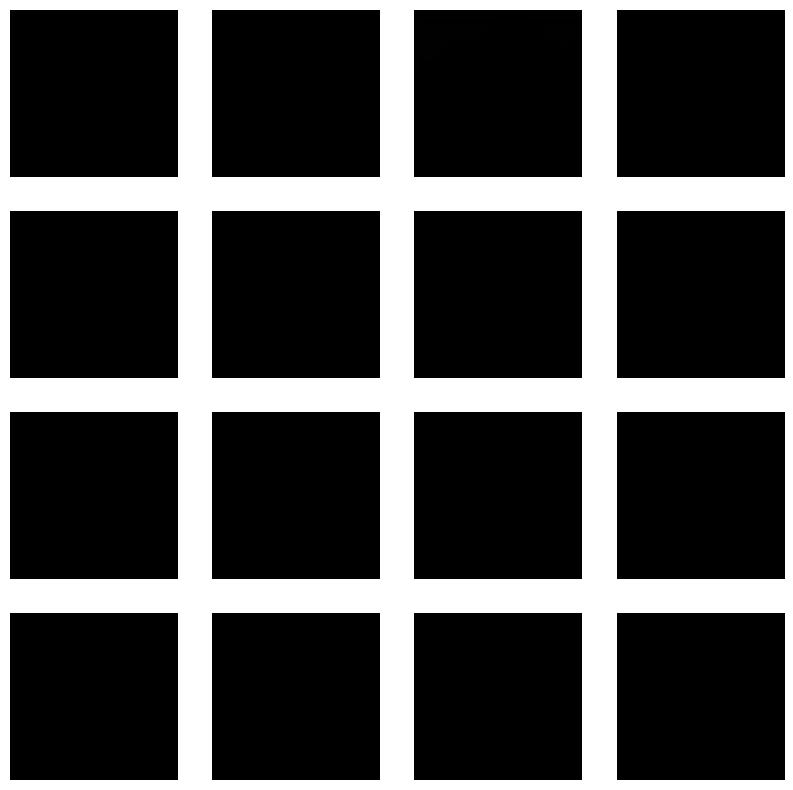

In [9]:
# Normalizing the pixel values for augmentation
x_train = x_train.astype('float32')/255.0
x_test = x_test.astype('float32')/255.0

# Displaying a sample of the training images
plt.figure(figsize=(10,10))
for i in range(16):
    plt.subplot(4,4, i+1)
    plt.imshow(x_train[i])
    plt.axis('off')
plt.show()


### **Create sample.jpg for the Lab**

In [15]:
from PIL import Image, ImageDraw

# Creating a blank white image
image = Image.new('RGB', (224,224), color=(255,255,255))

# Drawing a red square
draw = ImageDraw.Draw(image)
draw.rectangle([(50,50),(174,174)], fill=(255,0,0))



# Saving the image
image.save('shapes/rectangle.jpg')

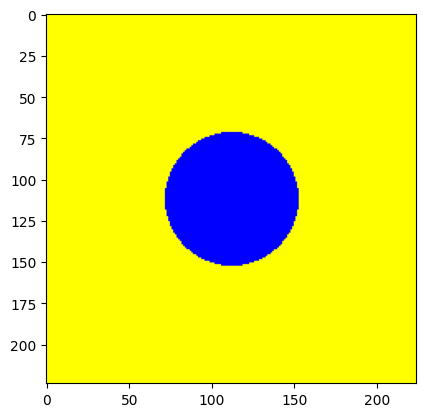

In [32]:
# Creating a blank yellow image
image = Image.new('RGB', (224,224), color=(255,255,0))

draw = ImageDraw.Draw(image)
draw.circle((112,112),radius=40,fill=(0,0,255))

image.save('shapes/circle.jpg')
plt.imshow(image)

In [22]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

# Load a sample image
img_path = "shapes/rectangle.jpg"
img = load_img(img_path)
x = img_to_array(img)
x = np.expand_dims(x, axis=0)
x.shape

(1, 224, 224, 3)

#### Step 2: Basic data augmentation 

Apply basic augmentations such as rotation, width shift, height shift, shear, zoom, and horizontal flip using the ImageDataGenerator as follows:

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

# Load the sample image
img_path = 'shapes/circle.jpg'
img = load_img(img_path)
x = img_to_array(img)
x = np.expand_dims(x, axis=0)


# Create an instance of ImageDataGenerator with basic augmentations
datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Generate batches of augmented images
i = 0
plt.figure(figsize=(100,100))
for i, batch in enumerate(datagen.flow(x, batch_size=1)):
    if i >= 8:
        break
    plt.subplot(3,3, i+1)
    plt.imshow(batch[0].astype('uint8'))
    i += 1
plt.show()

#### Feature-wise and sample-wise normalization 

Implement feature-wise and sample-wise normalization on the data set as follows: 

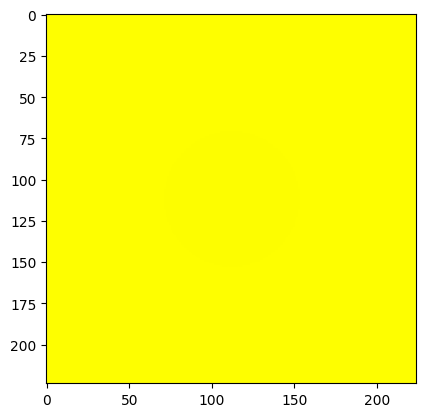

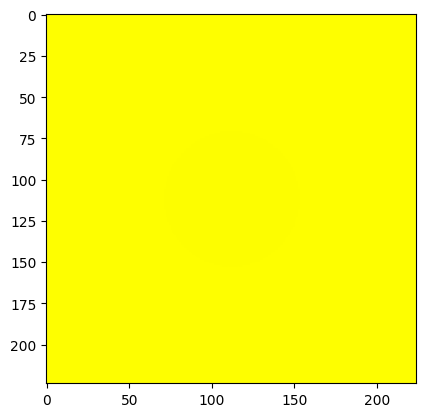

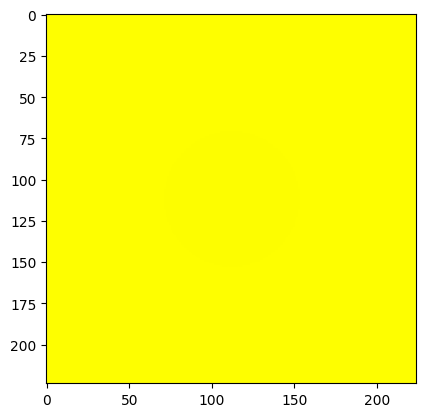

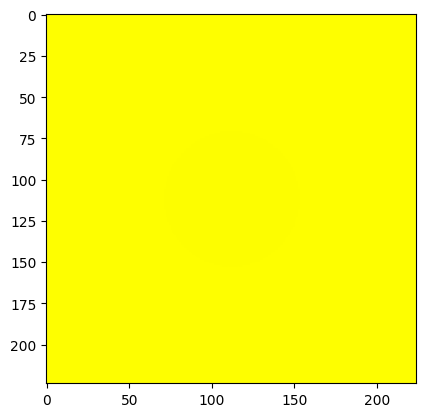

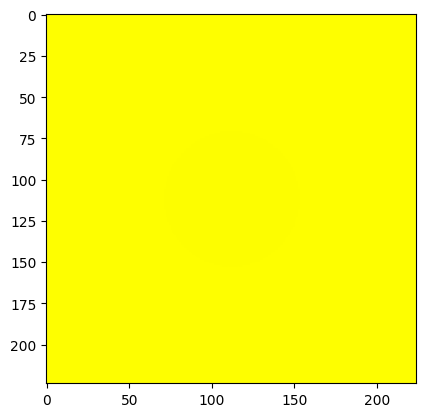

In [44]:
# Load the sample image
img_path = 'shapes/circle.jpg'
img = load_img(img_path)
x = img_to_array(img)
x = np.expand_dims(x, axis=0)

# Create an instance of ImageDataGenerator with normalization options
datagen = ImageDataGenerator(
    featurewise_center=True,
    featurewise_std_normalization=True,
    samplewise_center=True,
    samplewise_std_normalization=True
)

# Load the sample image again and fit the generator (normally done on the training set)
datagen.fit(x)

# Generating batches of normalized images
i = 0
for batch in datagen.flow(x, batch_size=1):
    plt.figure(i)
    imgplot = plt.imshow(batch[0].astype('uint8'))
    i += 1
    if i % 5 == 0:
        break

plt.show()

#### Custom data augmentation function 

Next, you define and apply a custom augmentation function that adds random noise to images as follows: 

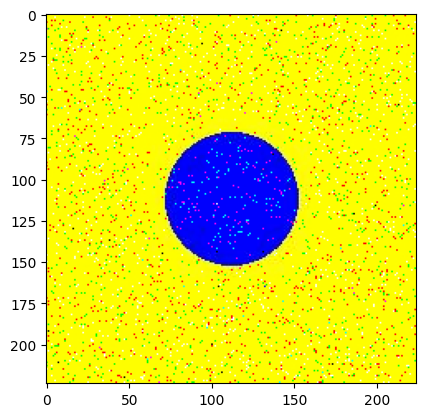

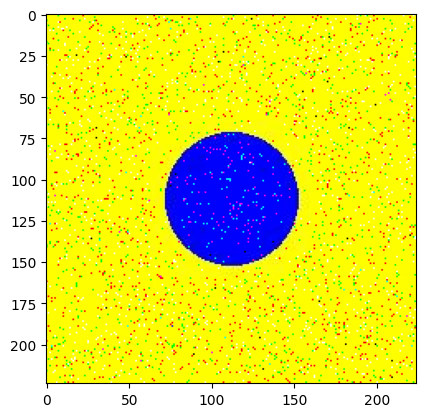

In [38]:
# Defining a custom data augmentation function
def add_random_noise(image):
    noise = np.random.normal(0,0.5,image.shape)
    return image + noise

# Create an instance of ImageDataGenerator with the custom augmentation
datagen = ImageDataGenerator(preprocessing_function=add_random_noise)

# Generate batches of augmented images with noise
i = 0
for batch in datagen.flow(x, batch_size=1):
    plt.figure(i)
    imgplot = plt.imshow(batch[0].astype('uint8'))
    i += 1
    if i % 2 == 0:
        break

plt.show()

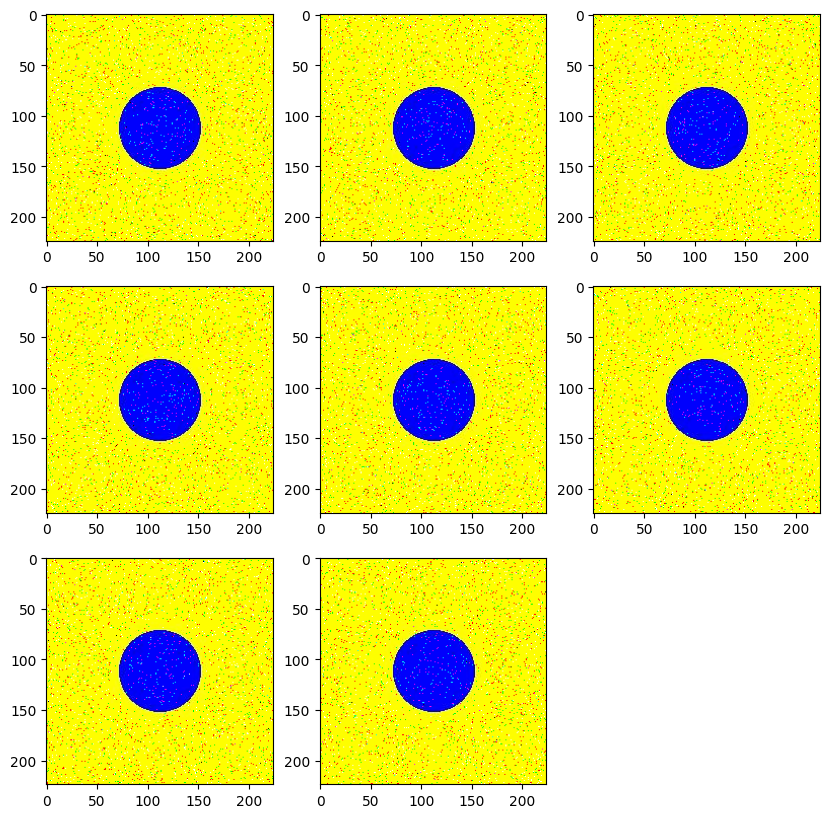

In [39]:
# Visualizing multiple augmented versions of the same image
plt.figure(figsize=(10,10))
for i, batch in enumerate(datagen.flow(x, batch_size=1)):
    if i >= 8:
        break
    plt.subplot(3,3, i+1)
    plt.imshow(batch[0].astype('uint8'))
plt.show()